# NOISE

In [1]:
import pandas as pd
import numpy as np  # Import numpy for mean calculations

# Initialize lists to store means and standard deviations
means = []
std_devs = []

for i in range(1, 41):  # Adjust range as needed
    # Generate the filename
    filename = f'enh_num_20_r_0.1_g_0.1_s1_0.950_s2_1.010_ma_5.5_mr_5.5_AC_10_RC_10_t{i}.txt'
    
    # Read the data
    df = pd.read_csv(filename, header=None, sep='\s+')
    df.columns = [f'key{i}', f'AC{i}', f'Cluster{i}']
    
    # Filter the rows where AC column equals 0
    filtered_df = df[df[f'AC{i}'] == 10]
    
    # Calculate mean and standard deviation of the Cluster column
    mean_cluster = filtered_df[f'Cluster{i}'].mean()
    std_cluster = filtered_df[f'Cluster{i}'].std()
    
    # Store the results
    means.append(mean_cluster)
    std_devs.append(std_cluster)
    
    # Print the results for each file
    noise = std_cluster / mean_cluster if mean_cluster != 0 else None
#     print(f"File {i}: Mean = {mean_cluster}, Std = {std_cluster}, Noise = {noise}")

# Calculate and print overall means and standard deviations at the end
overall_mean = np.mean(means)
overall_std_dev = np.mean(std_devs)
overall_noise=overall_std_dev/overall_mean
print(f"Overall Mean of Means: {overall_mean}")
print(f"Overall Mean of Standard Deviations: {overall_std_dev}")
print(f"Overall Mean of noise: {overall_noise}")



Overall Mean of Means: 7.109329686593732
Overall Mean of Standard Deviations: 5.077701420810224
Overall Mean of noise: 0.7142306862467488


# UNI/BI

# Time weighted average

In [10]:
import pandas as pd
import numpy as np

# Initialize variables to store the histogram and total time
num_clusters = 20  # Adjust based on expected number of cluster sizes
hist = np.zeros(num_clusters)  # Initialize histogram with zeros using NumPy
total_time = 0.0  # Variable to store the total accumulated time

# List of file indices to read from
file_list = [f'enh_num_20_r_0.007_g_0.008_s1_0.950_s2_1.010_ma_5.05_mr_0.51_AC_1_t{i}.txt' for i in range(1, 2)]

# Read all files and concatenate into a single DataFrame for better performance
dfs = [pd.read_csv(filename, header=None, sep='\s+', names=['key', 'AC', 'time', 'Cluster']) for filename in file_list]
concatenated_df = pd.concat(dfs, ignore_index=True)

# Calculate the total time and time associated with each cluster size
# Use NumPy arrays for faster calculations
time_values = concatenated_df['time'].values  # Extract time values
clusters = concatenated_df['Cluster'].values.astype(int)  # Extract cluster values and convert to integers

# Accumulate histogram and total time using vectorized operations
valid_mask = (clusters >= 1) & (clusters <= num_clusters)  # Filter valid cluster ranges
hist += np.bincount(clusters[valid_mask] - 1, weights=time_values[valid_mask], minlength=num_clusters)  # Accumulate times
total_time = np.sum(time_values[valid_mask])  # Calculate total time for valid cluster sizes

# Normalize histogram values by total accumulated time to get probabilities
if total_time > 0:
    hist /= total_time

# Create a DataFrame for the histogram
ke_df = pd.DataFrame({
    'cl': np.arange(1, num_clusters + 1),# Cluster indices (1 to num_clusters)
    'prob':hist                          # Normalized histogram values (probabilities)
})

# Save the histogram DataFrame to a text file, similar to the Fortran output
ke_df.to_csv('time_weighted_avg_clusters.txt', header=True, sep=' ', index=False)

# Display the resulting histogram DataFrame
print(ke_df)


    cl      prob
0    1  0.032197
1    2  0.043023
2    3  0.048346
3    4  0.058739
4    5  0.063015
5    6  0.066131
6    7  0.063716
7    8  0.055160
8    9  0.049502
9   10  0.042509
10  11  0.039425
11  12  0.039641
12  13  0.039844
13  14  0.043531
14  15  0.049549
15  16  0.051496
16  17  0.056685
17  18  0.054710
18  19  0.052019
19  20  0.050760


In [11]:
ke_df

,cl,prob
0,1,0.032197
1,2,0.043023
2,3,0.048346
3,4,0.058739
4,5,0.063015
5,6,0.066131
6,7,0.063716
7,8,0.055160
8,9,0.049502
9,10,0.042509


In [3]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns


# # Initialize an empty list to store DataFrames
# df_list = []

# # Loop through file indices from 1 to 15
# for i in range(1, 41):  # Adjust range as needed
#     # Generate the filename
#     filename = f'enh_num_20_r_10.0_g_1.0_s1_0.950_s2_1.010_ma_5.5_mr_5.5_AC_10_RC_10_t{i}.txt'
    
#     # Read the file into a DataFrame
#     df = pd.read_csv(filename, header=None, sep='\s+')
#     df.columns = [f'key{i}', f'AC{i}',f'time{i}', f'Cluster{i}']
    
#     # Append the DataFrame to the list
#     df_list.append(df)

# # Concatenate all DataFrames in the list along the index axis
# concatenated_df = pd.concat(df_list, axis=1)
# # Assuming 'concatenated_df' is your DataFrame
# # Selecting only the cluster columns
# cluster_columns = [f'Cluster{i}' for i in range(1, 41)]
# clusters_df = concatenated_df[cluster_columns]

# # Merging all the cluster columns into a single column
# merged_clusters = clusters_df.melt(value_name='MergedClusters').dropna()['MergedClusters']
# # clusters_df
# ke = merged_clusters.value_counts(normalize=True).sort_index()
# # Plotting the distribution of the merged column
# # plt.figure(figsize=(10, 6))
# # sns.histplot(merged_clusters, kde=True, bins=30)  # KDE for smooth distribution curve
# # plt.title('Distribution of Merged Clusters')
# # plt.xlabel('Values')
# # plt.ylabel('Frequency')
# # plt.show()
# # Convert 'ke' Series to a DataFrame with columns 'cl' and 'prob'
# ke_df = ke.reset_index()
# ke_df.columns = ['cl', 'prob']

# # Save the DataFrame to a text file with space as the separator
# ke_df.to_csv('whole_enh_num_20_r_10.0_g_1.0_s1_0.950_s2_1.010_ma_5.5_mr_5.5_AC_10_RC_100.txt', header=True, sep=' ', index=False)


# PLOT to show UNI/BI

In [12]:
df1=pd.read_csv('time_weighted_avg_clusters.txt',sep=' ')
# df2=pd.read_csv('time_weighted_avg_clusters_4.txt',sep=' ')
# df2=pd.read_csv('whole_enh_num_20_r_10.0_g_1.0_s1_0.950_s2_1.010_ma_5.5_mr_5.5_AC_10_RC_100.txt',sep='\s+')
# df3=pd.read_csv('whole_enh_num_20_r_10.0_g_3.0_s1_0.950_s2_1.010_ma_5.5_mr_5.5_AC_10_RC_10.txt',sep='\s+')
# df4=pd.read_csv('whole_enh_num_20_r_10.0_g_5.0_s1_0.950_s2_1.010_ma_5.5_mr_5.5_AC_10_RC_10.txt',sep='\s+')
# df5=pd.read_csv('whole_enh_num_20_r_10.0_g_7.0_s1_0.950_s2_1.010_ma_5.5_mr_5.5_AC_10_RC_10.txt',sep='\s+')
# df6=pd.read_csv('whole_enh_num_20_r_10.0_g_10.0_s1_0.950_s2_1.010_ma_5.5_mr_5.5_AC_10_RC_10.txt',sep='\s+')
df1

,cl,prob
0,1,0.032197
1,2,0.043023
2,3,0.048346
3,4,0.058739
4,5,0.063015
5,6,0.066131
6,7,0.063716
7,8,0.055160
8,9,0.049502
9,10,0.042509


In [13]:
s=df1['prob'].sum()
s

0.9999999999999991

In [14]:
m = (df1['cl'] * df1['prob']).sum()
m

10.523958586026076

/opt/intel/oneapi/intelpython/latest/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/opt/intel/oneapi/intelpython/latest/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/opt/intel/oneapi/intelpython/latest/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


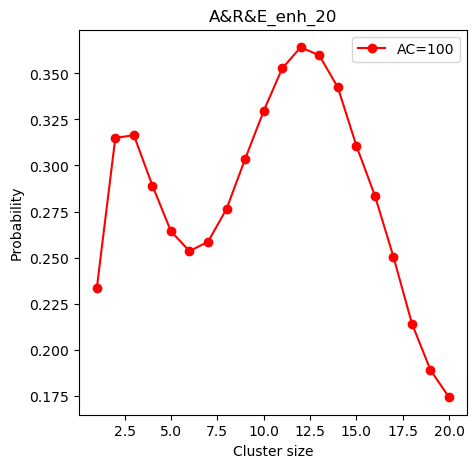

In [39]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(5,5))
plt.plot(df1.cl,df1.prob,'r-o',label='AC=100')
# plt.plot(df2.cl,df2.prob,'b-o',label='AC=10')
# plt.plot(df3.cl,df3.prob,'y-o',label='r=5,g=3')
# plt.plot(df4.cl,df4.prob,'m-o',label='r=5,g=4')
# plt.plot(df5.cl,df5.prob,'k-o',label='r=5,g=5')
# plt.plot(df6.cl,df6.prob,'g-o',label='r=5,g=5')
plt.xlabel('Cluster size')
plt.ylabel('Probability')
plt.legend()
plt.title('A&R&E_enh_20')
plt.show()

# Average cluster

In [ ]:
wa1 = (df1['cl'] * df1['prob']).sum() 
wa2 = (df2['cl'] * df2['prob']).sum()
wa3 = (df3['cl'] * df3['prob']).sum()
wa4 = (df4['cl'] * df4['prob']).sum()
wa5 = (df5['cl'] * df5['prob']).sum()
wa6 = (df6['cl'] * df6['prob']).sum()
print(wa1,wa2,wa3,wa4,wa5,wa6)

# Response time

In [105]:
import pandas as pd

# Initialize an empty list to store DataFrames
df_list = []

# Loop through file indices from 1 to 15
for i in range(1, 41):  # Adjust range as needed
    # Generate the filename
    filename = f'enh_num_20_r_10.0_g_3.0_s1_0.950_s2_1.010_ma_5.5_mr_5.5_AC_10_RC_10_t{i}.txt'
    
    # Read the file into a DataFrame
    df = pd.read_csv(filename, header=None, sep='\s+')
    df.columns = [f'key{i}', f'AC{i}', f'Cluster{i}']
    
    # Append the DataFrame to the list
    df_list.append(df)

# Concatenate all DataFrames in the list along the index axis
concatenated_df = pd.concat(df_list, axis=1)

# Find the index where the transition occurs (0 to 100) in the first AC column
transition_index = concatenated_df[concatenated_df.iloc[:, 1] == 10].index[0]

# Calculate start index for the clipping window
start_index = max(transition_index - 10, 0)

# Find the index of the first maximum value in the 'Avg_cluster' column
cluster_columns = [col for col in concatenated_df.columns if 'Cluster' in col]
concatenated_df['Avg_cluster'] = concatenated_df[cluster_columns].mean(axis=1)
max_cluster = concatenated_df['Avg_cluster'].max() - 0
post_transition_avg_cluster = concatenated_df['Avg_cluster'].iloc[transition_index:]
max_cluster = post_transition_avg_cluster.max() - 2
# Find the index where Avg_cluster reaches max_cluster
max_index = concatenated_df[concatenated_df['Avg_cluster'] >= max_cluster].index[0]
max_index = min(transition_index + 80, len(df))
# Clip the dataframe based on start and max indices
clipped_df = concatenated_df.iloc[start_index:max_index + 1].reset_index(drop=True)
# Subtract each key column by its respective transition point key value
key_columns = [col for col in clipped_df.columns if 'key' in col]
for key_col in key_columns:
    key_transition_value = concatenated_df.at[transition_index, key_col]
    clipped_df[key_col] = clipped_df[key_col] - key_transition_value
# Save the final DataFrame to a file, if needed
clipped_df.to_csv('concatenated_output.csv', index=False)

# Print the final DataFrame
clipped_df_to_print = clipped_df[['key1', 'AC1', 'Avg_cluster']]
print(clipped_df_to_print)


        key1   AC1  Avg_cluster
0  -0.443832   0.0        2.400
1  -0.377444   0.0        2.125
2  -0.335944   0.0        2.325
3  -0.264888   0.0        2.000
4  -0.253835   0.0        2.425
..       ...   ...          ...
86  2.327339  10.0       13.550
87  2.360093  10.0       13.575
88  2.365146  10.0       13.475
89  2.395242  10.0       13.275
90  2.404246  10.0       13.325

[91 rows x 3 columns]


C:\Users\User1\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\optimize\_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Optimal parameters: a=7.523204135407974, b=3.867849428325146,c=1.0


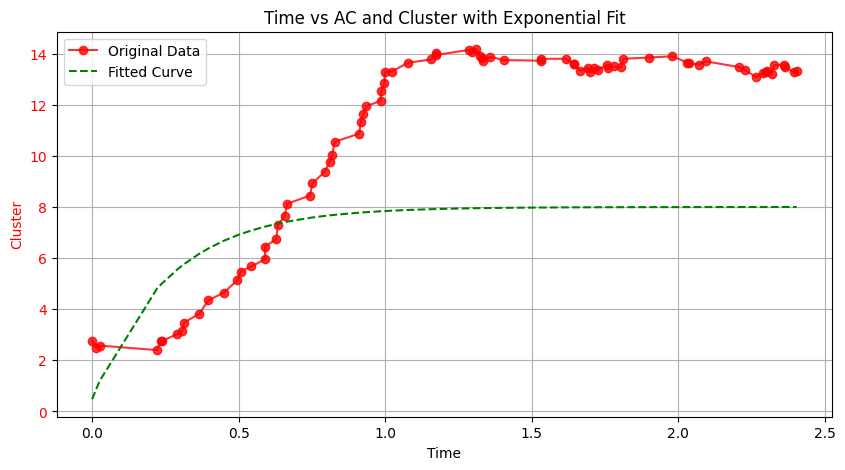

response time=0.25854160523332975


In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Assuming df3 is already defined
df3 = clipped_df.iloc[10:]

# Define the exponential function
def exponential_func(x, a, b,c):
    return 8 - a*np.exp(-b*x)

# Extract the data for fitting
x_data = df3['key1'].values
y_data = df3['Avg_cluster'].values 

# Normalize x_data
#x_data_normalized = x_data - np.min(x_data)

# Provide initial guesses for parameters a and b


# Use curve_fit to fit the exponential function to the normalized data
popt, pcov = curve_fit(exponential_func, x_data, y_data)

# Get the optimal parameters
a, b,c = popt
print(f"Optimal parameters: a={a}, b={b},c={c}")

# Generate y values based on the fit
y_fit = exponential_func(x_data, *popt)

# Create the figure and the first axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot the original dataset
ax1.plot(x_data, y_data, 'r-o', alpha=0.8, label='Original Data')
ax1.set_xlabel('Time')
ax1.set_ylabel('Cluster', color='r')
ax1.tick_params(axis='y', labelcolor='r')
# ax1.set_ylim(2, 16.5)

# Plot the fitted exponential curve
ax1.plot(x_data, y_fit, 'g--', label='Fitted Curve')
ax1.legend()

# Create the second axis, sharing the same x-axis
# ax2 = ax1.twinx()

# Plot the second dataset
# ax2.plot(df3['key1'], df3['AC1'], 'b-o', alpha=0.8)
# ax2.set_ylabel('AC', color='b')
# ax2.tick_params(axis='y', labelcolor='b')

# Show the plot
plt.title('Time vs AC and Cluster with Exponential Fit')
plt.grid(True)
plt.show()
print(f"response time={1/b}")